
TABLE 1: SUMMARY STATISTICS
          count          mean           std           min           max
b_i_flfp  140.0  2.639560e+01  6.295400e+00  1.080080e+01  3.659640e+01
b_i_gdp   140.0  1.304078e+03  1.084164e+03  2.720649e+02  4.515568e+03
b_i_upop  140.0  1.166369e+08  1.498885e+08  2.772785e+06  5.133251e+08

Inference (Table 1):
The variables show reasonable spread (std > 0), indicating enough variation for regression.
Min-max ranges differ across variables, so coefficient magnitudes should be interpreted with scale in mind.

TABLE 2: MODEL SELECTION TESTS
                        Test     Stat  P-Value
       F-Test (Pooled vs FE) 108.8961   0.0000
          Hausman (FE vs RE)   0.0413   0.9795
Breusch-Pagan (Pooled vs RE) 941.9594   0.0000

Inference (Table 2):
F-test is significant: pooled OLS is rejected in favor of a panel model (FE/RE).
Hausman is not significant: RE is acceptable versus FE.
Breusch-Pagan LM is significant: RE is preferred over pooled OLS.

--- FINAL MODEL

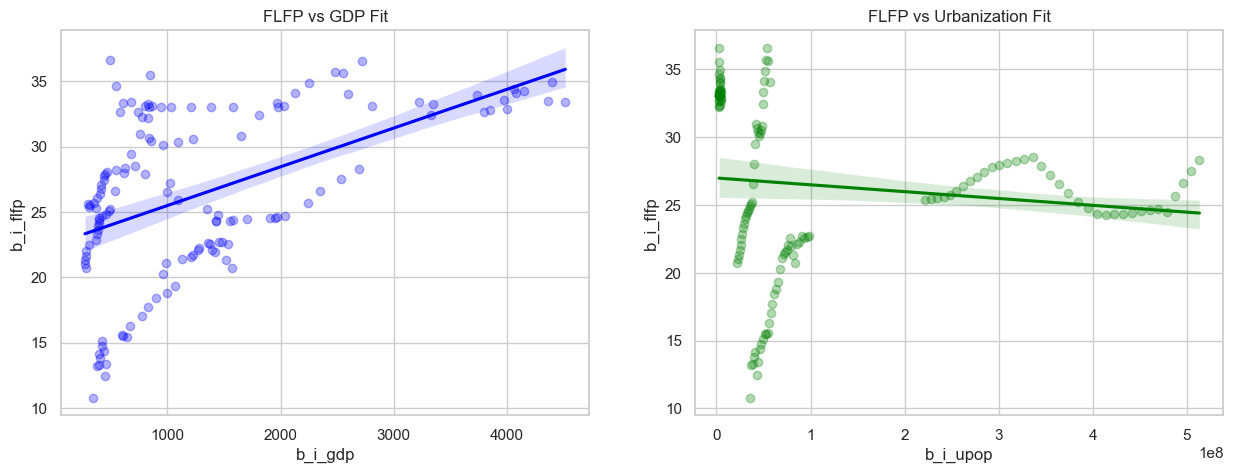

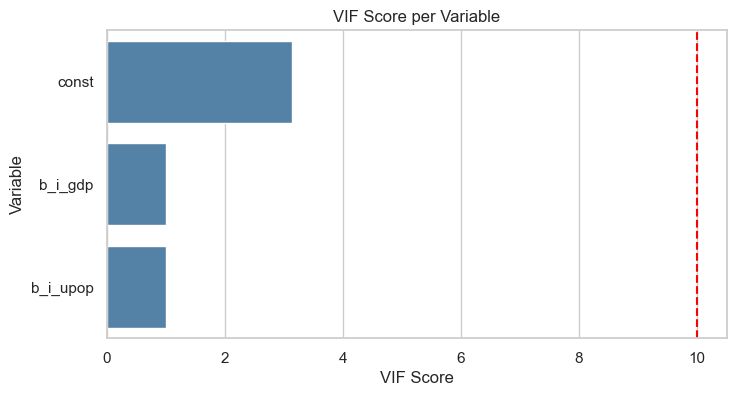

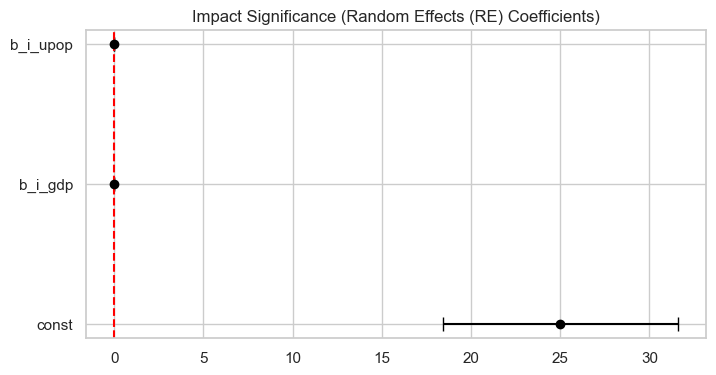

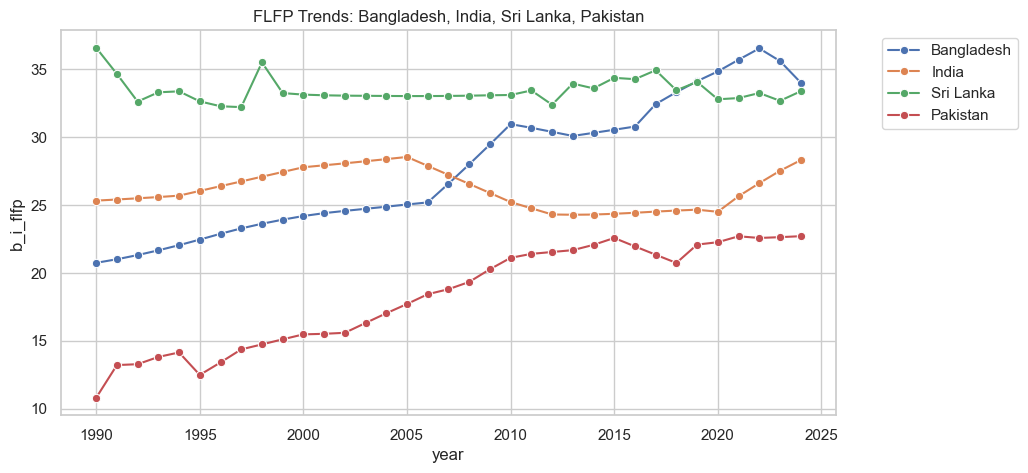

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
from linearmodels.panel import PooledOLS, PanelOLS, RandomEffects
from statsmodels.stats.outliers_influence import variance_inflation_factor

# --- 1. DATA PREPARATION & ENCODING ---
try:
    df = pd.read_csv("CIA Dataset - encoded data (1).csv")
except FileNotFoundError:
    exit("Error: 'CIA Dataset - encoded data (1).csv' not found.")

# Encoding countries as requested
country_map = {1: "Bangladesh", 2: "India", 3: "Sri Lanka", 4: "Pakistan"}
entity_col, time_col = 'country_id', 'year'
cols = [entity_col, time_col, 'b_i_flfp', 'b_i_gdp', 'b_i_upop']

d = df[cols].copy()
for c in ['b_i_flfp', 'b_i_gdp', 'b_i_upop']:
    d[c] = pd.to_numeric(d[c], errors='coerce')

d = d.dropna().set_index([entity_col, time_col]).sort_index()

y = d['b_i_flfp']
X_vars = ['b_i_gdp', 'b_i_upop']
X_panel = d[X_vars]
X_with_const = sm.add_constant(X_panel)

# --- 2. MODEL ESTIMATION ---
pooled = PooledOLS(y, X_with_const).fit(cov_type='robust')
fe = PanelOLS(y, X_panel, entity_effects=True).fit(cov_type='robust')
re = RandomEffects(y, X_with_const).fit(cov_type='robust')
ols = sm.OLS(y, X_with_const).fit()

# --- 3. MODEL SELECTION TESTS ---

# A. F-Test (Pooled vs FE)
f_stat, f_pval = fe.f_pooled.stat, fe.f_pooled.pval

# B. Hausman Test (FE vs RE)
def perform_hausman(fe, re):
    b_diff = fe.params - re.params.loc[fe.params.index]
    v_diff = fe.cov - re.cov.loc[fe.params.index, fe.params.index]
    stat = np.dot(np.dot(b_diff.T, np.linalg.inv(v_diff)), b_diff)
    df_h = b_diff.shape[0]
    pval = 1 - stats.chi2.cdf(stat, df_h)
    return stat, pval

h_stat, h_pval = perform_hausman(fe, re)

# C. Breusch-Pagan LM Test (Pooled vs RE)
res_pooled = pooled.resids
n, t = d.index.get_level_values(0).nunique(), d.index.get_level_values(1).nunique()
lm_stat = (n * t / (2 * (t - 1))) * (((res_pooled.groupby(level=0).sum()**2).sum() / (res_pooled**2).sum()) - 1)**2
lm_pval = 1 - stats.chi2.cdf(lm_stat, 1)

# --- 4. PRINTING TABLES & INFERENCES ---

print("\n" + "="*60)
print("TABLE 1: SUMMARY STATISTICS")
print("="*60)
print(d.describe().T[['count', 'mean', 'std', 'min', 'max']].round(4))
print("\nInference (Table 1):")
print("The variables show reasonable spread (std > 0), indicating enough variation for regression.")
print("Min-max ranges differ across variables, so coefficient magnitudes should be interpreted with scale in mind.")

print("\n" + "="*60)
print("TABLE 2: MODEL SELECTION TESTS")
print("="*60)
test_results = pd.DataFrame({
    'Test': ['F-Test (Pooled vs FE)', 'Hausman (FE vs RE)', 'Breusch-Pagan (Pooled vs RE)'],
    'Stat': [f_stat, h_stat, lm_stat],
    'P-Value': [f_pval, h_pval, lm_pval]
}).round(4)
print(test_results.to_string(index=False))
print("\nInference (Table 2):")
if f_pval < 0.05:
    print("F-test is significant: pooled OLS is rejected in favor of a panel model (FE/RE).")
else:
    print("F-test is not significant: pooled structure may be adequate.")
if h_pval < 0.05:
    print("Hausman is significant: FE is preferred over RE.")
else:
    print("Hausman is not significant: RE is acceptable versus FE.")
if lm_pval < 0.05:
    print("Breusch-Pagan LM is significant: RE is preferred over pooled OLS.")
else:
    print("Breusch-Pagan LM is not significant: pooled OLS may be sufficient over RE.")

print("\n--- FINAL MODEL SELECTION INFERENCE ---")
if f_pval < 0.05 and h_pval < 0.05:
    best_model = fe
    best_name = "Fixed Effects (FE)"
    print("Decision: Use FE Model (Significant F-test and Hausman).")
elif f_pval < 0.05 and h_pval >= 0.05:
    best_model = re
    best_name = "Random Effects (RE)"
    print("Decision: Use RE Model (Significant F-test, non-significant Hausman).")
else:
    best_model = pooled
    best_name = "Pooled OLS"
    print("Decision: Use Pooled OLS (No significant individual effects).")

vif_df = pd.DataFrame({
    "Variable": X_with_const.columns,
    "VIF Score": [round(variance_inflation_factor(X_with_const.values, i), 4) for i in range(X_with_const.shape[1])]
})
print("\n" + "="*60)
print("TABLE 3: MULTICOLLINEARITY (VIF)")
print("="*60)
print(vif_df.to_string(index=False))
print("\nInference (Table 3):")
high_vif = vif_df[(vif_df["Variable"] != "const") & (vif_df["VIF Score"] > 10)]
if high_vif.empty:
    print("No severe multicollinearity among predictors (all non-constant VIF <= 10).")
else:
    print("Potential severe multicollinearity detected (non-constant VIF > 10):")
    print(", ".join(high_vif["Variable"].tolist()))

# Table 4: Predicted vs Actual
d_res = d.reset_index()
d_res['Country Name'] = d_res[entity_col].map(country_map)
d_res['Predicted'] = best_model.predict(X_panel if best_name=="Fixed Effects (FE)" else X_with_const).values
act_vs_pred = d_res[['year', 'Country Name', 'b_i_flfp', 'Predicted']].round(4)
print("\n" + "="*60)
print(f"TABLE 4: ACTUAL VS PREDICTED ({best_name})")
print("="*60)
print(act_vs_pred.head(15).to_string(index=False))
mae = (d_res['b_i_flfp'] - d_res['Predicted']).abs().mean()
rmse = np.sqrt(((d_res['b_i_flfp'] - d_res['Predicted']) ** 2).mean())
print("\nInference (Table 4):")
print(f"Average absolute prediction error (MAE): {mae:.4f}")
print(f"Root mean squared error (RMSE): {rmse:.4f}")

# Table 5: Regular Linear Regression (OLS)
ols_table = pd.DataFrame({
    "Variable": ols.params.index,
    "Coefficient": ols.params.values,
    "Std. Error": ols.bse.values,
    "t-Stat": ols.tvalues.values,
    "P-Value": ols.pvalues.values
}).round(4)
print("\n" + "="*60)
print("TABLE 5: REGULAR LINEAR REGRESSION (OLS)")
print("="*60)
print(ols_table.to_string(index=False))
print(f"\nModel Fit (OLS): R-squared={ols.rsquared:.4f}, Adjusted R-squared={ols.rsquared_adj:.4f}")
print("Inference (Table 5):")
sig_vars = ols_table[ols_table["P-Value"] < 0.05]["Variable"].tolist()
if sig_vars:
    print("Statistically significant OLS terms at 5% level:", ", ".join(sig_vars))
else:
    print("No OLS terms are statistically significant at 5% level.")

# Table 6: Chosen Model Coefficient Significance (IV adequacy check)
best_coef_table = pd.DataFrame({
    "Variable": best_model.params.index,
    "Coefficient": best_model.params.values,
    "P-Value": best_model.pvalues.values
}).round(4)
print("\n" + "="*60)
print(f"TABLE 6: CHOSEN MODEL COEFFICIENT SIGNIFICANCE ({best_name})")
print("="*60)
print(best_coef_table.to_string(index=False))

iv_pvals = best_model.pvalues.reindex(X_vars)
sig_ivs = iv_pvals[iv_pvals < 0.05].index.tolist()
insig_ivs = iv_pvals[iv_pvals >= 0.05].index.tolist()
print("\nInference (Table 6):")
if len(sig_ivs) == len(X_vars):
    print("Both independent variables are statistically significant at 5%.")
    ivs_adequate = True
elif len(sig_ivs) == 0:
    print("Both independent variables are statistically insignificant at 5%.")
    print("Inference: The chosen IV set is not adequate to explain FLFP reliably in the selected model.")
    ivs_adequate = False
else:
    print("Only some independent variables are statistically significant at 5%.")
    print("Significant:", ", ".join(sig_ivs))
    print("Insignificant:", ", ".join(insig_ivs))
    print("Inference: The IV set is only partially adequate; variable selection should be refined.")
    ivs_adequate = False

# Final success conclusion
print("\n" + "="*60)
print("FINAL CONCLUSION: MODEL SUCCESS CHECK")
print("="*60)
success = (
    ((best_name == "Fixed Effects (FE)" and f_pval < 0.05 and h_pval < 0.05) or
     (best_name == "Random Effects (RE)" and f_pval < 0.05 and h_pval >= 0.05) or
     (best_name == "Pooled OLS" and f_pval >= 0.05))
    and (rmse < d['b_i_flfp'].std())
    and ivs_adequate
)
if success:
    print("The model is successful: specification tests, prediction error, and IV significance all support the model.")
else:
    print("The model is not fully successful: selected IVs are not sufficiently significant and/or diagnostics are not strong enough.")

# --- 5. VISUALIZATIONS ---
sns.set_theme(style="whitegrid")

# Figure 1: Multi-Predictor Fit
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.regplot(x='b_i_gdp', y='b_i_flfp', data=d_res, ax=axes[0], color='blue', scatter_kws={'alpha':0.3})
axes[0].set_title("FLFP vs GDP Fit")
sns.regplot(x='b_i_upop', y='b_i_flfp', data=d_res, ax=axes[1], color='green', scatter_kws={'alpha':0.3})
axes[1].set_title("FLFP vs Urbanization Fit")
plt.show()

# Figure 2: VIF Chart
plt.figure(figsize=(8, 4))
sns.barplot(x='VIF Score', y='Variable', data=vif_df, color='steelblue')
plt.axvline(10, color='red', linestyle='--', label='Threshold')
plt.title("VIF Score per Variable")
plt.show()

# Figure 3: Impact Significance (Best Model Coefficients)
plt.figure(figsize=(8, 4))
ci = best_model.conf_int()
plt.errorbar(best_model.params, best_model.params.index, xerr=(best_model.params - ci.iloc[:, 0]), fmt='o', color='black', capsize=5)
plt.axvline(0, color='red', linestyle='--')
plt.title(f"Impact Significance ({best_name} Coefficients)")
plt.show()

# Figure 4: Country Trends
plt.figure(figsize=(10, 5))
target_countries = [1, 2, 3, 4]
sns.lineplot(data=d_res[d_res[entity_col].isin(target_countries)], x=time_col, y='b_i_flfp', hue='Country Name', marker='o')
plt.title("FLFP Trends: Bangladesh, India, Sri Lanka, Pakistan")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()